In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
import os, time, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# ── Config ──────────────────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT   = "./data"
RESULTS_DIR = "./results"
os.makedirs(DATA_ROOT,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

# ── Hyperparameters ─────────────────────────────────────────────────────────
num_classes = 10
num_epochs  = 10
batch_size  = 64
lr          = 1e-3
summary     = {}

Device: cuda


In [3]:
num_classes = 10
num_epochs  = 10
batch_size  = 64
lr          = 1e-3

summary = {}

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 1 — Load MNIST Data
# ════════════════════════════════════════════════════════════════════════════
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = torchvision.datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} samples | Test: {len(test_ds):,} samples")

Train: 60,000 samples | Test: 10,000 samples


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 2 — Model Definitions
# ════════════════════════════════════════════════════════════════════════════

# ── Scratch RNN Cell ─────────────────────────────────────────────────────────
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_x = nn.Linear(input_size,  hidden_size, bias=True)
        self.W_h = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x, h_prev):
        # h_t = tanh(W_x * x_t + W_h * h_{t-1})
        return torch.tanh(self.W_x(x) + self.W_h(h_prev))


# ── Scratch Multi-Layer RNN ───────────────────────────────────────────────────
class VanillaRNNScratch(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, scan="row"):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.scan        = scan

        sizes = [input_size] + [hidden_size] * num_layers
        self.cells = nn.ModuleList([
            VanillaRNNCell(sizes[i], sizes[i+1]) for i in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        if self.scan == "col":
            x = x.transpose(1, 2)

        B, T, _ = x.shape
        h = [torch.zeros(B, self.hidden_size, device=x.device)
             for _ in range(self.num_layers)]

        for t in range(T):
            inp = x[:, t, :]
            for i, cell in enumerate(self.cells):
                h[i] = cell(inp, h[i])
                inp   = h[i]

        return self.fc(h[-1])


# ── PyTorch Built-in RNN ─────────────────────────────────────────────────────
class VanillaRNNPyTorch(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, scan="row", dropout=0.0):
        super().__init__()
        self.scan = scan
        self.rnn  = nn.RNN(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        if self.scan == "col":
            x = x.transpose(1, 2)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 3 — Training Utilities
# ════════════════════════════════════════════════════════════════════════════

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class GradientMonitor:
    def __init__(self, model):
        self.grad_norms = {}
        self._hooks     = []
        for name, param in model.named_parameters():
            if param.requires_grad:
                def _hook(grad, n=name):
                    self.grad_norms.setdefault(n, []).append(grad.norm().item())
                self._hooks.append(param.register_hook(_hook))

    def remove(self):
        for h in self._hooks:
            h.remove()


def train_one_epoch(model, loader, optimizer, criterion, grad_clip=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (model(imgs).argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        total_loss += criterion(out, labels).item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader,
                num_epochs=10, lr=1e-3, label="model",
                grad_clip=None, monitor_grads=False,
                patience=5, verbose=True):

    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    monitor   = GradientMonitor(model) if monitor_grads else None

    results = dict(
        label=label, params=count_parameters(model),
        train_loss=[], val_loss=[],
        train_acc=[],  val_acc=[],
        epoch_times=[], grad_norms={},
    )

    best_acc, best_state, no_improve = 0.0, None, 0

    for epoch in range(num_epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, grad_clip)
        va_loss, va_acc = evaluate(model, test_loader, criterion)
        elapsed = time.time() - t0

        results["train_loss"].append(tr_loss)
        results["val_loss"].append(va_loss)
        results["train_acc"].append(tr_acc)
        results["val_acc"].append(va_acc)
        results["epoch_times"].append(elapsed)

        if verbose:
            print(f"  [{label}] Ep {epoch+1:>2}/{num_epochs}  "
                  f"Loss {tr_loss:.4f}/{va_loss:.4f}  "
                  f"Acc {tr_acc:.4f}/{va_acc:.4f}  ({elapsed:.1f}s)")

        if va_acc > best_acc:
            best_acc, best_state, no_improve = va_acc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose: print(f"  Early stop @ epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    results["best_val_acc"]    = best_acc
    results["avg_epoch_time"]  = np.mean(results["epoch_times"])
    if monitor:
        results["grad_norms"] = monitor.grad_norms
        monitor.remove()

    return results, model

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# STEP 4 — Visualisation Utilities
# ════════════════════════════════════════════════════════════════════════════

def plot_curves(results_list, title="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for res in results_list:
        ax1.plot(res["train_loss"], "--", label=f"{res['label']} train")
        ax1.plot(res["val_loss"],         label=f"{res['label']} val")
        ax2.plot(res["train_acc"],  "--")
        ax2.plot(res["val_acc"],          label=res["label"])
    ax1.set(title="Loss Curves",     xlabel="Epoch", ylabel="Loss")
    ax2.set(title="Accuracy Curves", xlabel="Epoch", ylabel="Accuracy")
    ax1.legend(fontsize=7); ax2.legend(fontsize=7)
    if title: fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show(); plt.close()


def plot_gradient_norms(grad_norms, label="", save_path=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    for name, norms in grad_norms.items():
        ax.plot(norms, label=name, alpha=0.75)
    ax.set(title=f"Gradient Magnitudes — {label}",
           xlabel="Update step", ylabel="||grad||")
    ax.legend(fontsize=6, ncol=3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show(); plt.close()


 PS1 — Vanilla RNN  |  Scratch vs PyTorch  |  Row vs Column scan
  [VanillaRNN-Scratch-Row] Ep  1/10  Loss 0.6648/0.3207  Acc 0.7941/0.9112  (24.1s)
  [VanillaRNN-Scratch-Row] Ep  2/10  Loss 0.2745/0.1980  Acc 0.9310/0.9475  (24.1s)
  [VanillaRNN-Scratch-Row] Ep  3/10  Loss 0.2040/0.1961  Acc 0.9519/0.9461  (24.0s)
  [VanillaRNN-Scratch-Row] Ep  4/10  Loss 0.1743/0.1593  Acc 0.9595/0.9576  (23.9s)
  [VanillaRNN-Scratch-Row] Ep  5/10  Loss 0.1584/0.1664  Acc 0.9628/0.9525  (23.7s)
  [VanillaRNN-Scratch-Row] Ep  6/10  Loss 0.1492/0.2360  Acc 0.9662/0.9359  (23.7s)
  [VanillaRNN-Scratch-Row] Ep  7/10  Loss 0.1381/0.1462  Acc 0.9687/0.9610  (23.8s)
  [VanillaRNN-Scratch-Row] Ep  8/10  Loss 0.1318/0.1318  Acc 0.9711/0.9645  (23.8s)
  [VanillaRNN-Scratch-Row] Ep  9/10  Loss 0.1222/0.1474  Acc 0.9732/0.9610  (23.7s)
  [VanillaRNN-Scratch-Row] Ep 10/10  Loss 0.1170/0.1214  Acc 0.9740/0.9687  (23.7s)
  [VanillaRNN-1L-Row] Ep  1/10  Loss 0.7627/0.3704  Acc 0.7572/0.8912  (14.1s)
  [VanillaRNN-1

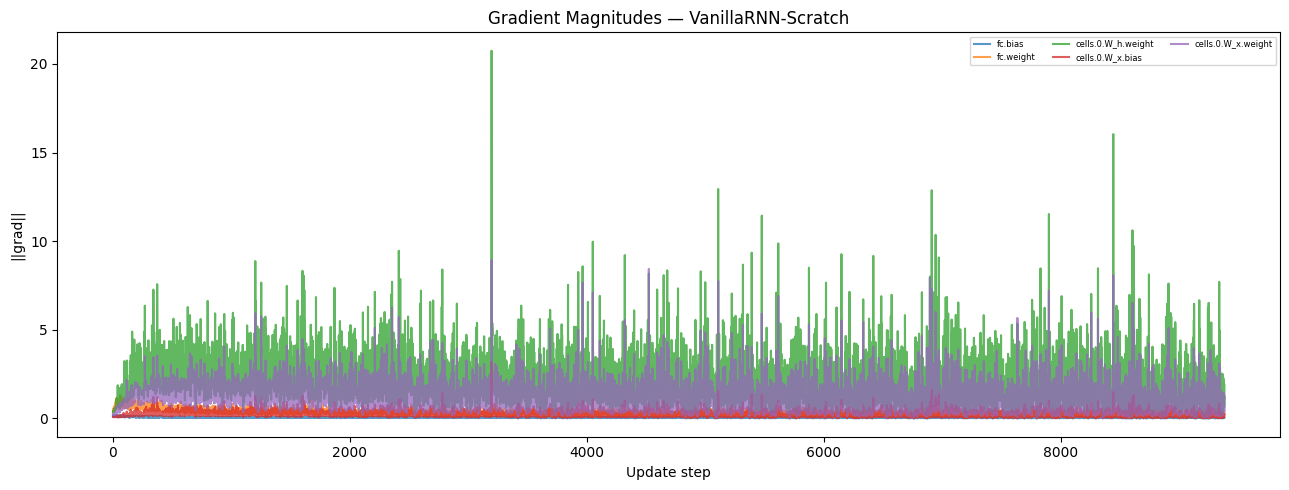

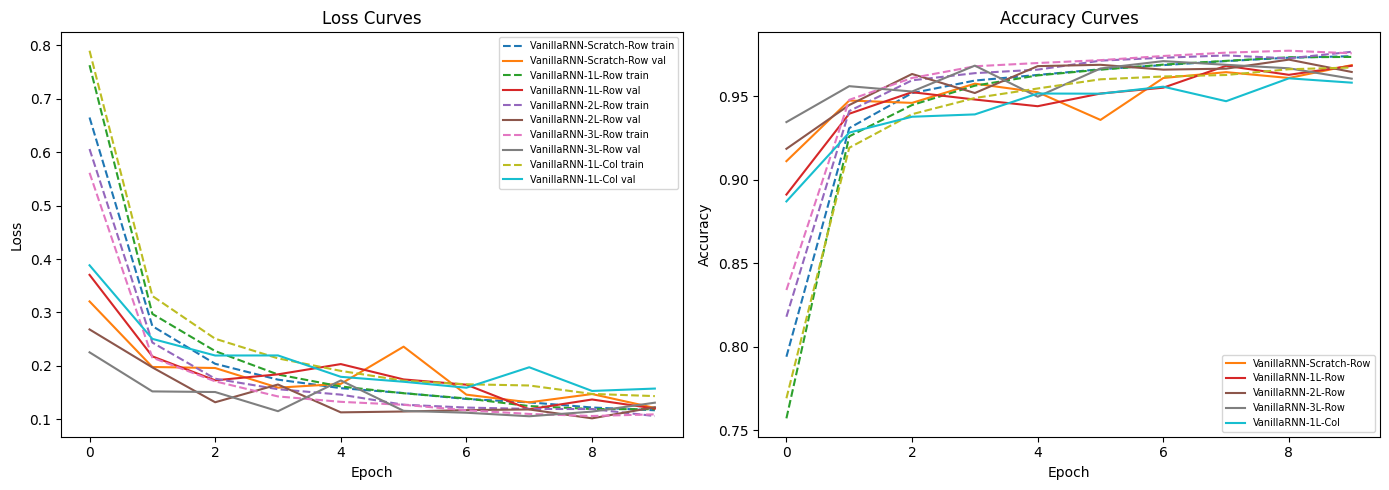

In [15]:
print("\n" + "="*65)
print(" PS1 — Vanilla RNN  |  Scratch vs PyTorch  |  Row vs Column scan")
print("="*65)

model_scratch = VanillaRNNScratch(hidden_size=128, num_layers=1,
                                  num_classes=num_classes, scan="row")
res_scratch, model_scratch = train_model(
    model_scratch, train_loader, test_loader,
    num_epochs=num_epochs, lr=lr,
    label="VanillaRNN-Scratch-Row",
    monitor_grads=True)

summary["VanillaRNN-Scratch-Row"] = res_scratch

for n_layers in [1, 2, 3]:
    tag   = f"VanillaRNN-{n_layers}L-Row"
    model = VanillaRNNPyTorch(hidden_size=128, num_layers=n_layers,
                               num_classes=num_classes, scan="row")
    res, _ = train_model(model, train_loader, test_loader,
                         num_epochs=num_epochs, lr=lr, label=tag)
    summary[tag] = res

model_col = VanillaRNNPyTorch(hidden_size=128, num_layers=1,
                               num_classes=num_classes, scan="col")
res_col, _ = train_model(model_col, train_loader, test_loader,
                          num_epochs=num_epochs, lr=lr,
                          label="VanillaRNN-1L-Col")

summary["VanillaRNN-1L-Col"] = res_col

plot_gradient_norms(res_scratch["grad_norms"], label="VanillaRNN-Scratch")

plot_curves([
    res_scratch,
    summary["VanillaRNN-1L-Row"],
    summary["VanillaRNN-2L-Row"],
    summary["VanillaRNN-3L-Row"],
    res_col
])

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# PS2 — LSTM
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*65)
print(" PS2 — LSTM  |  PyTorch  |  Row vs Column scan")
print("="*65)


 PS2 — LSTM  |  PyTorch  |  Row vs Column scan


In [17]:
class LSTMPyTorch(nn.Module):
    """
    Multi-layer LSTM using nn.LSTM.
    Same interface as RNN for fair comparison.
    """
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, scan="row", dropout=0.0):
        super().__init__()
        self.scan = scan

        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        if self.scan == "col":
            x = x.transpose(1, 2)

        out, _ = self.lstm(x)          # (B, T, H)
        return self.fc(out[:, -1, :])  # last time-step

In [18]:
# ── 2a: LSTM — 1 / 2 / 3 layers (row-wise) ────────────────────────────────
print("\n[2a] LSTM — 1, 2, 3 layers (row-wise)")

for n_layers in [1, 2, 3]:
    tag = f"LSTM-{n_layers}L-Row"
    model = LSTMPyTorch(hidden_size=128, num_layers=n_layers,
                        num_classes=num_classes, scan="row")

    res, _ = train_model(
        model, train_loader, test_loader,
        num_epochs=num_epochs, lr=lr,
        label=tag)

    summary[tag] = res


# ── 2b: Column-wise scan ──────────────────────────────────────────────────
print("\n[2b] LSTM — 1 layer, column-wise scan")

model_lstm_col = LSTMPyTorch(hidden_size=128, num_layers=1,
                             num_classes=num_classes, scan="col")

res_lstm_col, _ = train_model(
    model_lstm_col, train_loader, test_loader,
    num_epochs=num_epochs, lr=lr,
    label="LSTM-1L-Col")

summary["LSTM-1L-Col"] = res_lstm_col


[2a] LSTM — 1, 2, 3 layers (row-wise)
  [LSTM-1L-Row] Ep  1/10  Loss 0.3691/0.1048  Acc 0.8939/0.9712  (15.6s)
  [LSTM-1L-Row] Ep  2/10  Loss 0.0958/0.0738  Acc 0.9783/0.9772  (15.8s)
  [LSTM-1L-Row] Ep  3/10  Loss 0.0652/0.0602  Acc 0.9860/0.9813  (15.6s)
  [LSTM-1L-Row] Ep  4/10  Loss 0.0507/0.0598  Acc 0.9901/0.9812  (15.7s)
  [LSTM-1L-Row] Ep  5/10  Loss 0.0409/0.0467  Acc 0.9921/0.9862  (15.5s)
  [LSTM-1L-Row] Ep  6/10  Loss 0.0371/0.0611  Acc 0.9936/0.9829  (15.6s)
  [LSTM-1L-Row] Ep  7/10  Loss 0.0297/0.0473  Acc 0.9948/0.9861  (15.6s)
  [LSTM-1L-Row] Ep  8/10  Loss 0.0258/0.0501  Acc 0.9958/0.9857  (15.5s)
  [LSTM-1L-Row] Ep  9/10  Loss 0.0233/0.0495  Acc 0.9966/0.9849  (15.6s)
  [LSTM-1L-Row] Ep 10/10  Loss 0.0211/0.0456  Acc 0.9967/0.9864  (15.7s)
  [LSTM-2L-Row] Ep  1/10  Loss 0.3179/0.0996  Acc 0.9096/0.9686  (18.4s)
  [LSTM-2L-Row] Ep  2/10  Loss 0.0808/0.0609  Acc 0.9829/0.9824  (18.5s)
  [LSTM-2L-Row] Ep  3/10  Loss 0.0544/0.0514  Acc 0.9898/0.9849  (18.5s)
  [LSTM-2L-R

In [22]:
def plot_comparison_bar(summary_dict, metric="best_val_acc",
                        title=None, save_path=None):
    names  = list(summary_dict.keys())
    values = [summary_dict[n][metric] for n in names]

    colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

    fig, ax = plt.subplots(figsize=(max(8, len(names)*1.4), 5))
    bars = ax.bar(names, values, color=colors, edgecolor="white")

    ax.bar_label(bars, fmt="%.4f", fontsize=8)

    ax.set(
        ylabel=metric,
        title=title or f"Model Comparison — {metric}"
    )

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)

    plt.show()
    plt.close()

def print_summary_table(summary_dict):
    print(f"\n{'Model':<35} {'Val Acc':>9} {'Params':>10} {'Avg Ep(s)':>10}")
    print("-" * 68)
    
    for name, res in summary_dict.items():
        print(
            f"{name:<35} "
            f"{res['best_val_acc']:>9.4f} "
            f"{res['params']:>10,} "
            f"{res['avg_epoch_time']:>10.2f}"
        )

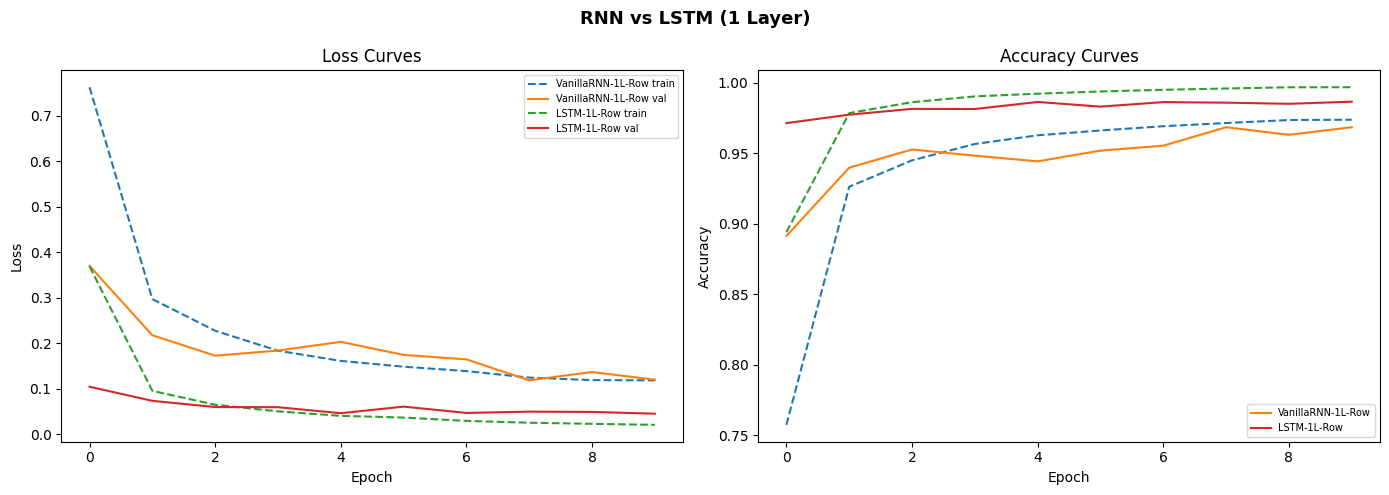

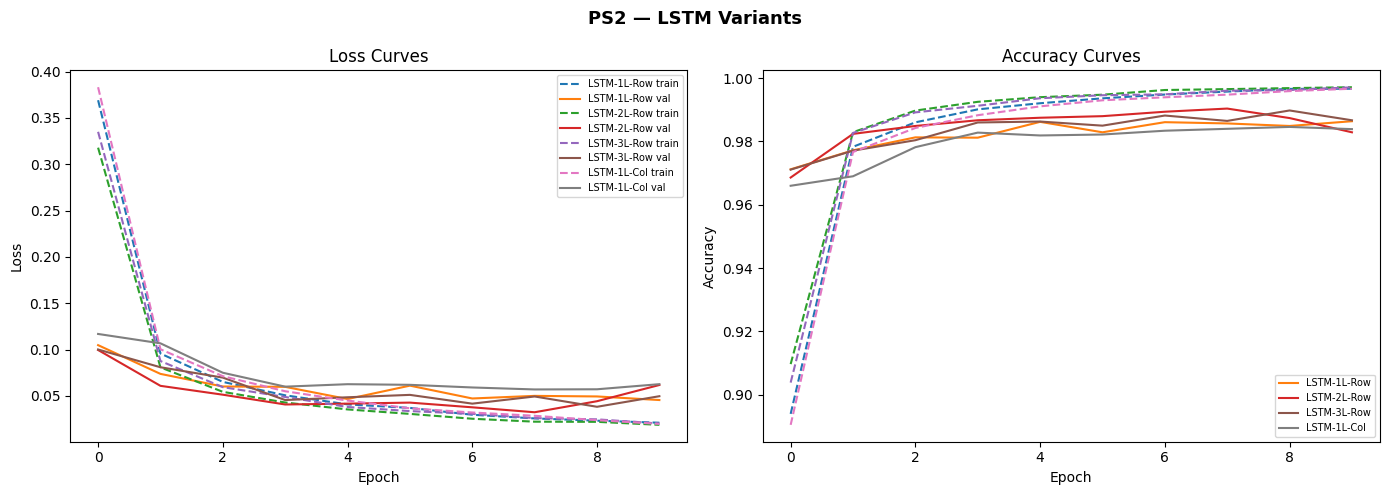

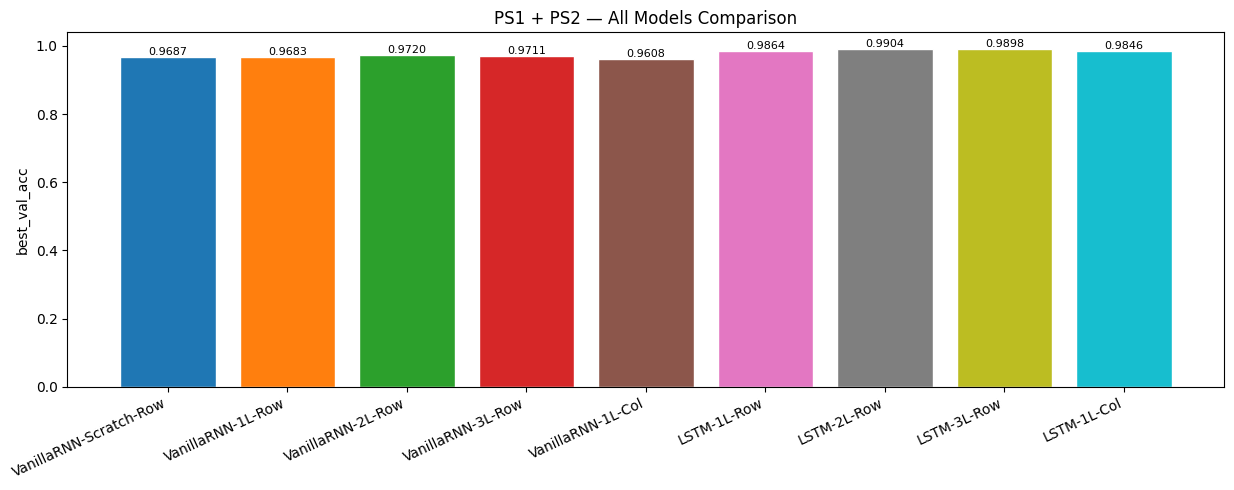


Model                                 Val Acc     Params  Avg Ep(s)
--------------------------------------------------------------------
VanillaRNN-Scratch-Row                 0.9687     21,386      23.86
VanillaRNN-1L-Row                      0.9683     21,514      14.20
VanillaRNN-2L-Row                      0.9720     54,538      14.75
VanillaRNN-3L-Row                      0.9711     87,562      15.00
VanillaRNN-1L-Col                      0.9608     21,514      14.13
LSTM-1L-Row                            0.9864     82,186      15.63
LSTM-2L-Row                            0.9904    214,282      18.45
LSTM-3L-Row                            0.9898    346,378      20.05
LSTM-1L-Col                            0.9846     82,186      15.77


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# PS2 — Plots
# ════════════════════════════════════════════════════════════════════════════

# Compare RNN vs LSTM (1 layer)
plot_curves(
    [
        summary["VanillaRNN-1L-Row"],
        summary["LSTM-1L-Row"]
    ],
    title="RNN vs LSTM (1 Layer)",
    save_path=os.path.join(RESULTS_DIR, "ps2_rnn_vs_lstm.png")
)


# LSTM variants comparison
plot_curves(
    [
        summary["LSTM-1L-Row"],
        summary["LSTM-2L-Row"],
        summary["LSTM-3L-Row"],
        summary["LSTM-1L-Col"]
    ],
    title="PS2 — LSTM Variants",
    save_path=os.path.join(RESULTS_DIR, "ps2_lstm_curves.png")
)


# Bar comparison (all models)
plot_comparison_bar(
    summary,
    metric="best_val_acc",
    title="PS1 + PS2 — All Models Comparison",
    save_path=os.path.join(RESULTS_DIR, "ps2_all_models_bar.png")
)

print_summary_table(summary)

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# PS3 — GRU
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*65)
print(" PS3 — GRU  |  PyTorch  |  Row vs Column scan")
print("="*65)


 PS3 — GRU  |  PyTorch  |  Row vs Column scan


In [25]:
class GRUPyTorch(nn.Module):
    """
    Multi-layer GRU using nn.GRU.
    Same interface as RNN & LSTM for fair comparison.
    """
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, scan="row", dropout=0.0):
        super().__init__()
        self.scan = scan

        self.gru = nn.GRU(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        if self.scan == "col":
            x = x.transpose(1, 2)

        out, _ = self.gru(x)          # (B, T, H)
        return self.fc(out[:, -1, :]) # last time-step

In [26]:
# ── 3a: GRU — 1 / 2 / 3 layers (row-wise) ────────────────────────────────
print("\n[3a] GRU — 1, 2, 3 layers (row-wise)")

for n_layers in [1, 2, 3]:
    tag = f"GRU-{n_layers}L-Row"

    model = GRUPyTorch(hidden_size=128, num_layers=n_layers,
                       num_classes=num_classes, scan="row")

    res, _ = train_model(
        model, train_loader, test_loader,
        num_epochs=num_epochs, lr=lr,
        label=tag)

    summary[tag] = res


# ── 3b: Column-wise scan ──────────────────────────────────────────────────
print("\n[3b] GRU — 1 layer, column-wise scan")

model_gru_col = GRUPyTorch(hidden_size=128, num_layers=1,
                           num_classes=num_classes, scan="col")

res_gru_col, _ = train_model(
    model_gru_col, train_loader, test_loader,
    num_epochs=num_epochs, lr=lr,
    label="GRU-1L-Col")

summary["GRU-1L-Col"] = res_gru_col


[3a] GRU — 1, 2, 3 layers (row-wise)
  [GRU-1L-Row] Ep  1/10  Loss 0.3865/0.0941  Acc 0.8848/0.9702  (15.1s)
  [GRU-1L-Row] Ep  2/10  Loss 0.0830/0.0762  Acc 0.9808/0.9791  (14.8s)
  [GRU-1L-Row] Ep  3/10  Loss 0.0571/0.0621  Acc 0.9871/0.9820  (15.0s)
  [GRU-1L-Row] Ep  4/10  Loss 0.0439/0.0571  Acc 0.9906/0.9814  (14.6s)
  [GRU-1L-Row] Ep  5/10  Loss 0.0346/0.0553  Acc 0.9931/0.9834  (14.6s)
  [GRU-1L-Row] Ep  6/10  Loss 0.0303/0.0511  Acc 0.9943/0.9850  (14.7s)
  [GRU-1L-Row] Ep  7/10  Loss 0.0254/0.0488  Acc 0.9955/0.9870  (14.9s)
  [GRU-1L-Row] Ep  8/10  Loss 0.0205/0.0449  Acc 0.9966/0.9874  (14.8s)
  [GRU-1L-Row] Ep  9/10  Loss 0.0177/0.0450  Acc 0.9973/0.9874  (14.9s)
  [GRU-1L-Row] Ep 10/10  Loss 0.0175/0.0480  Acc 0.9976/0.9871  (14.8s)
  [GRU-2L-Row] Ep  1/10  Loss 0.3230/0.0939  Acc 0.9051/0.9725  (16.5s)
  [GRU-2L-Row] Ep  2/10  Loss 0.0735/0.0603  Acc 0.9831/0.9825  (16.5s)
  [GRU-2L-Row] Ep  3/10  Loss 0.0486/0.0477  Acc 0.9899/0.9842  (16.6s)
  [GRU-2L-Row] Ep  4/10  L

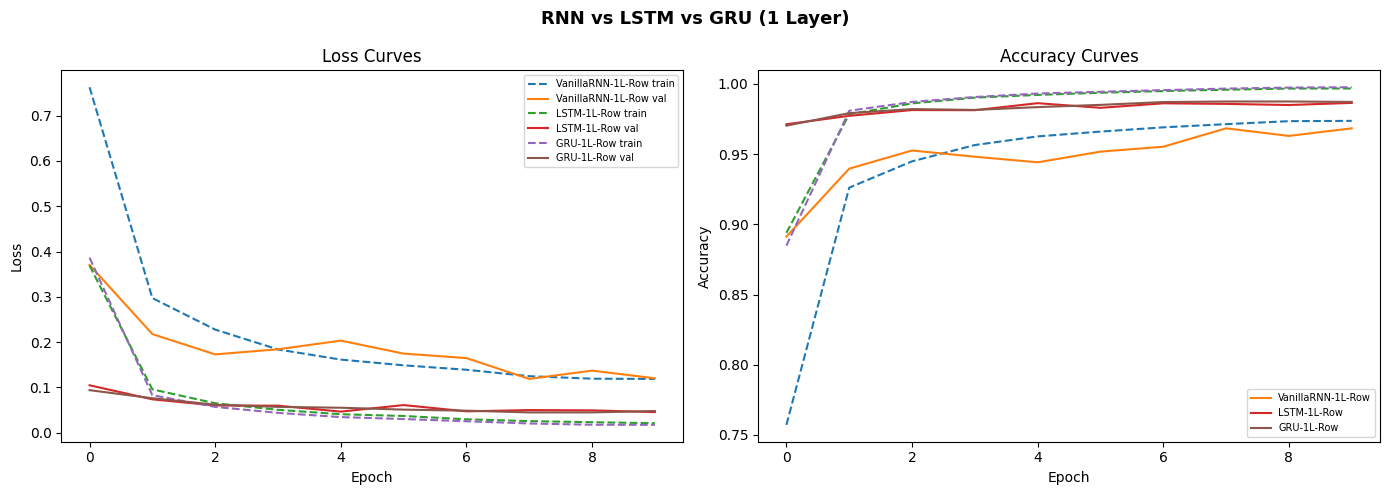

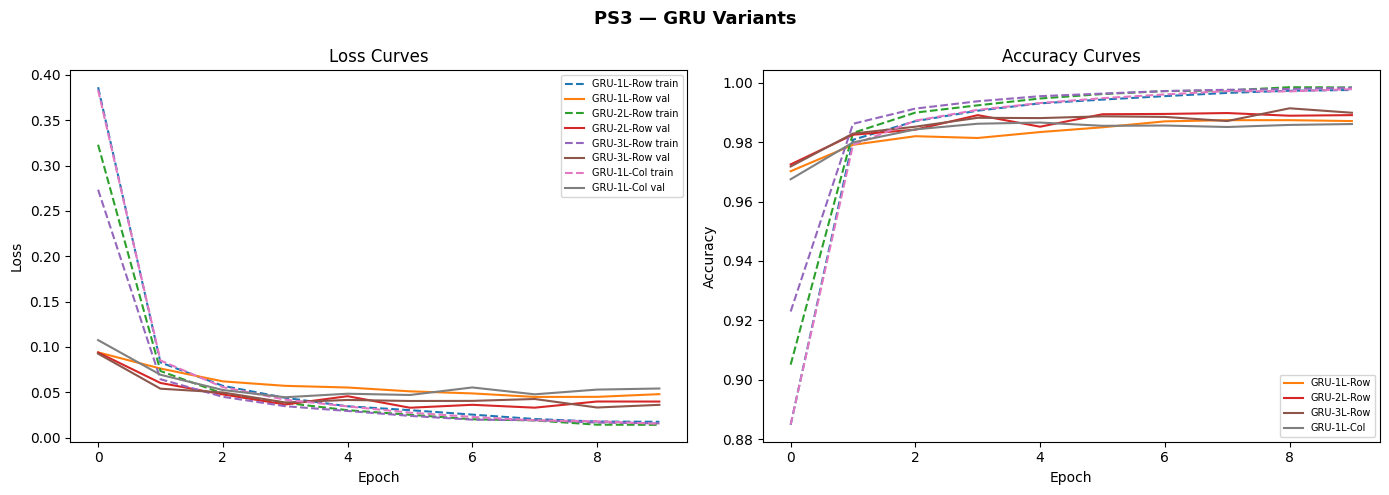

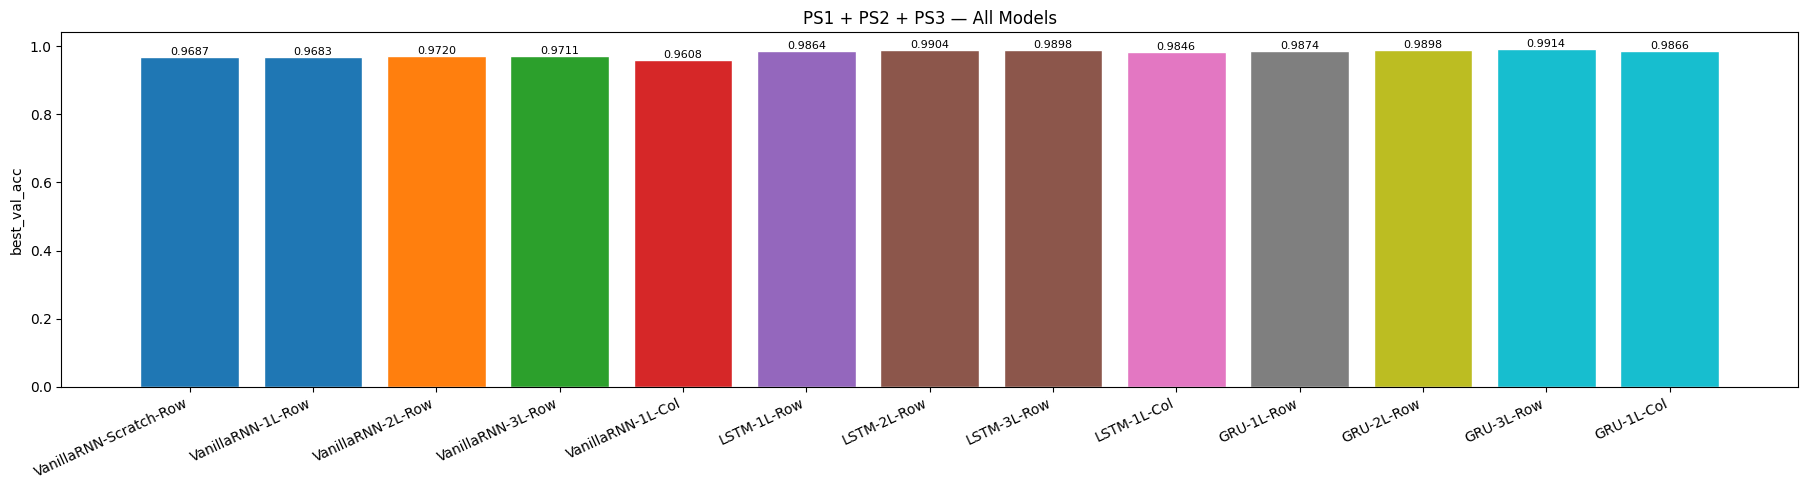


Model                                 Val Acc     Params  Avg Ep(s)
--------------------------------------------------------------------
VanillaRNN-Scratch-Row                 0.9687     21,386      23.86
VanillaRNN-1L-Row                      0.9683     21,514      14.20
VanillaRNN-2L-Row                      0.9720     54,538      14.75
VanillaRNN-3L-Row                      0.9711     87,562      15.00
VanillaRNN-1L-Col                      0.9608     21,514      14.13
LSTM-1L-Row                            0.9864     82,186      15.63
LSTM-2L-Row                            0.9904    214,282      18.45
LSTM-3L-Row                            0.9898    346,378      20.05
LSTM-1L-Col                            0.9846     82,186      15.77
GRU-1L-Row                             0.9874     61,962      14.83
GRU-2L-Row                             0.9898    161,034      16.53
GRU-3L-Row                             0.9914    260,106      18.38
GRU-1L-Col                             0.9866 

In [27]:
# ════════════════════════════════════════════════════════════════════════════
# PS3 — Comparisons
# ════════════════════════════════════════════════════════════════════════════

# Compare single layer models
plot_curves(
    [
        summary["VanillaRNN-1L-Row"],
        summary["LSTM-1L-Row"],
        summary["GRU-1L-Row"]
    ],
    title="RNN vs LSTM vs GRU (1 Layer)",
    save_path=os.path.join(RESULTS_DIR, "ps3_rnn_lstm_gru.png")
)


# Compare GRU variants
plot_curves(
    [
        summary["GRU-1L-Row"],
        summary["GRU-2L-Row"],
        summary["GRU-3L-Row"],
        summary["GRU-1L-Col"]
    ],
    title="PS3 — GRU Variants",
    save_path=os.path.join(RESULTS_DIR, "ps3_gru_curves.png")
)


# Final comparison (all models)
plot_comparison_bar(
    summary,
    metric="best_val_acc",
    title="PS1 + PS2 + PS3 — All Models",
    save_path=os.path.join(RESULTS_DIR, "ps3_all_models.png")
)

print_summary_table(summary)

In [28]:
# ════════════════════════════════════════════════════════════════════════════
# PS3 — Analysis (Theory)
# ════════════════════════════════════════════════════════════════════════════

print("\n--- GRU vs LSTM Analysis ---\n")

print("j) Accuracy, Training Time, Parameters:")
print("""
- LSTM usually gives slightly higher accuracy than GRU
- GRU trains faster due to fewer gates
- GRU has fewer parameters → more efficient
""")

print("k) Computational Efficiency:")
print("""
- GRU has 2 gates (reset, update)
- LSTM has 3 gates (input, forget, output)
- Hence:
    GRU → fewer FLOPs, less memory
    LSTM → more expressive but heavier
""")

print("l) Stacked GRU Layers:")
print("""
- 1 layer → fast, basic learning
- 2 layers → better feature extraction
- 3 layers → diminishing returns, possible overfitting
""")

print("m) When to prefer GRU:")
print("""
- When dataset is small
- When faster training is needed
- When memory is limited
- When performance difference is negligible
""")


--- GRU vs LSTM Analysis ---

j) Accuracy, Training Time, Parameters:

- LSTM usually gives slightly higher accuracy than GRU
- GRU trains faster due to fewer gates
- GRU has fewer parameters → more efficient

k) Computational Efficiency:

- GRU has 2 gates (reset, update)
- LSTM has 3 gates (input, forget, output)
- Hence:
    GRU → fewer FLOPs, less memory
    LSTM → more expressive but heavier

l) Stacked GRU Layers:

- 1 layer → fast, basic learning
- 2 layers → better feature extraction
- 3 layers → diminishing returns, possible overfitting

m) When to prefer GRU:

- When dataset is small
- When faster training is needed
- When memory is limited
- When performance difference is negligible



In [29]:
# ════════════════════════════════════════════════════════════════════════════
# PS4 — Bidirectional RNNs (BiLSTM & BiGRU)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*65)
print(" PS4 — Bidirectional Models  |  BiLSTM & BiGRU")
print("="*65)


 PS4 — Bidirectional Models  |  BiLSTM & BiGRU


In [30]:
class BiLSTM(nn.Module):
    """
    Bidirectional LSTM with:
    - concat → doubles feature size
    - avg → keeps same size
    """
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, scan="row", mode="concat"):
        super().__init__()
        self.scan = scan
        self.mode = mode

        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        if mode == "concat":
            self.fc = nn.Linear(hidden_size * 2, num_classes)
        else:  # avg
            self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        if self.scan == "col":
            x = x.transpose(1, 2)

        out, _ = self.lstm(x)  # (B, T, 2H)

        if self.mode == "concat":
            final = out[:, -1, :]  # last timestep (2H)
        else:
            forward = out[:, -1, :self.lstm.hidden_size]
            backward = out[:, 0, self.lstm.hidden_size:]
            final = (forward + backward) / 2

        return self.fc(final)

In [31]:
class BiGRU(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, scan="row"):
        super().__init__()
        self.scan = scan

        self.gru = nn.GRU(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        if self.scan == "col":
            x = x.transpose(1, 2)

        out, _ = self.gru(x)   # (B, T, 2H)
        return self.fc(out[:, -1, :])

In [32]:
print("\n[4a] BiLSTM — concat vs avg")

# Concat
model_bilstm_concat = BiLSTM(mode="concat")
res_concat, _ = train_model(
    model_bilstm_concat, train_loader, test_loader,
    num_epochs=num_epochs, lr=lr,
    label="BiLSTM-Concat")

summary["BiLSTM-Concat"] = res_concat


# Avg
model_bilstm_avg = BiLSTM(mode="avg")
res_avg, _ = train_model(
    model_bilstm_avg, train_loader, test_loader,
    num_epochs=num_epochs, lr=lr,
    label="BiLSTM-Avg")

summary["BiLSTM-Avg"] = res_avg


print("\n[4b] Bidirectional GRU")

model_bigru = BiGRU()
res_bigru, _ = train_model(
    model_bigru, train_loader, test_loader,
    num_epochs=num_epochs, lr=lr,
    label="BiGRU")

summary["BiGRU"] = res_bigru


[4a] BiLSTM — concat vs avg
  [BiLSTM-Concat] Ep  1/10  Loss 0.3768/0.1167  Acc 0.8934/0.9646  (18.5s)
  [BiLSTM-Concat] Ep  2/10  Loss 0.0974/0.0752  Acc 0.9779/0.9772  (18.3s)
  [BiLSTM-Concat] Ep  3/10  Loss 0.0704/0.0630  Acc 0.9853/0.9818  (18.5s)
  [BiLSTM-Concat] Ep  4/10  Loss 0.0521/0.0573  Acc 0.9897/0.9837  (18.1s)
  [BiLSTM-Concat] Ep  5/10  Loss 0.0443/0.0499  Acc 0.9915/0.9855  (18.2s)
  [BiLSTM-Concat] Ep  6/10  Loss 0.0378/0.0425  Acc 0.9931/0.9879  (18.2s)
  [BiLSTM-Concat] Ep  7/10  Loss 0.0310/0.0429  Acc 0.9944/0.9878  (18.5s)
  [BiLSTM-Concat] Ep  8/10  Loss 0.0272/0.0480  Acc 0.9953/0.9856  (18.3s)
  [BiLSTM-Concat] Ep  9/10  Loss 0.0253/0.0489  Acc 0.9960/0.9860  (18.2s)
  [BiLSTM-Concat] Ep 10/10  Loss 0.0215/0.0443  Acc 0.9965/0.9876  (18.5s)
  [BiLSTM-Avg] Ep  1/10  Loss 0.3261/0.0977  Acc 0.9122/0.9693  (18.3s)
  [BiLSTM-Avg] Ep  2/10  Loss 0.0803/0.0740  Acc 0.9829/0.9763  (18.4s)
  [BiLSTM-Avg] Ep  3/10  Loss 0.0565/0.0581  Acc 0.9890/0.9824  (18.4s)
  [Bi

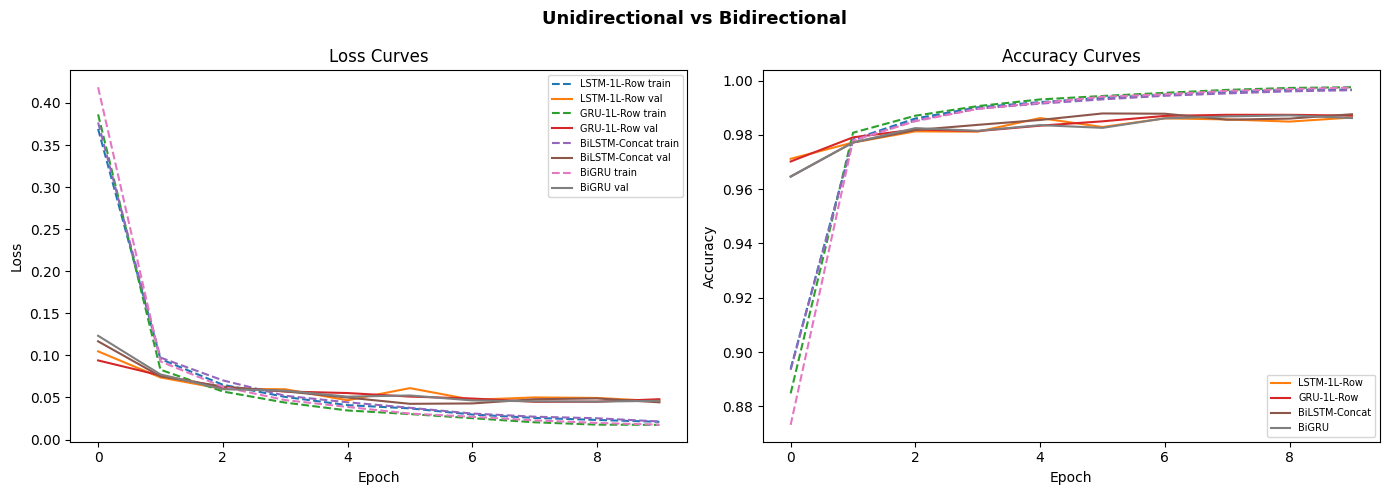

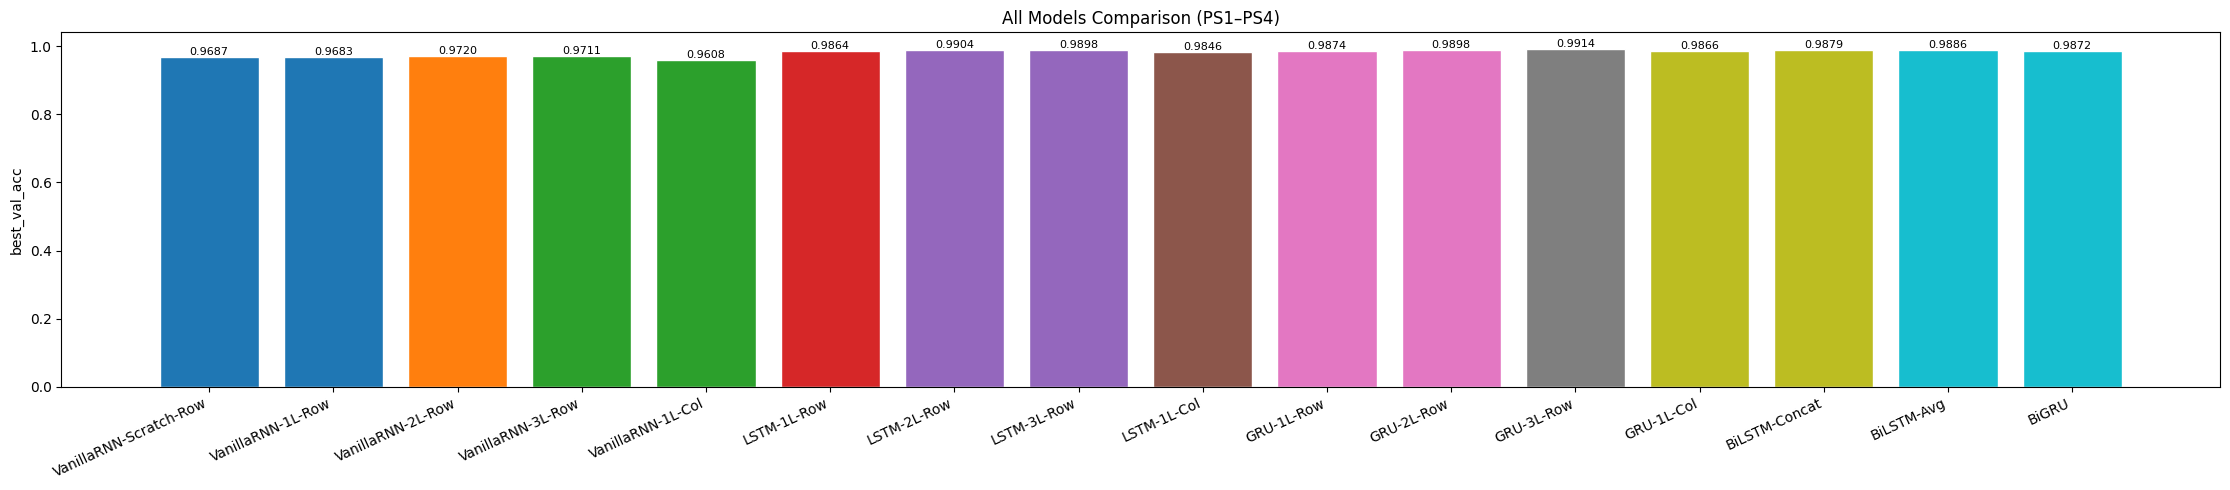


Model                                 Val Acc     Params  Avg Ep(s)
--------------------------------------------------------------------
VanillaRNN-Scratch-Row                 0.9687     21,386      23.86
VanillaRNN-1L-Row                      0.9683     21,514      14.20
VanillaRNN-2L-Row                      0.9720     54,538      14.75
VanillaRNN-3L-Row                      0.9711     87,562      15.00
VanillaRNN-1L-Col                      0.9608     21,514      14.13
LSTM-1L-Row                            0.9864     82,186      15.63
LSTM-2L-Row                            0.9904    214,282      18.45
LSTM-3L-Row                            0.9898    346,378      20.05
LSTM-1L-Col                            0.9846     82,186      15.77
GRU-1L-Row                             0.9874     61,962      14.83
GRU-2L-Row                             0.9898    161,034      16.53
GRU-3L-Row                             0.9914    260,106      18.38
GRU-1L-Col                             0.9866 

In [33]:
# Compare LSTM vs BiLSTM vs GRU vs BiGRU
plot_curves(
    [
        summary["LSTM-1L-Row"],
        summary["GRU-1L-Row"],
        summary["BiLSTM-Concat"],
        summary["BiGRU"]
    ],
    title="Unidirectional vs Bidirectional",
    save_path=os.path.join(RESULTS_DIR, "ps4_bi_vs_uni.png")
)


plot_comparison_bar(
    summary,
    metric="best_val_acc",
    title="All Models Comparison (PS1–PS4)",
    save_path=os.path.join(RESULTS_DIR, "ps4_all_models.png")
)

print_summary_table(summary)

In [34]:
print("\n--- PS4 Analysis ---\n")

print("n) BiLSTM concat vs avg:")
print("""
- Concat → higher dimensional features → better accuracy
- Avg → simpler, fewer params, slightly lower performance
""")


print("o) BiLSTM vs LSTM:")
print("""
- BiLSTM uses both past and future context
- Usually improves accuracy slightly
- But doubles computation
""")


print("p) BiGRU vs BiLSTM:")
print("""
- BiGRU is faster and lighter
- BiLSTM may perform slightly better
- Trade-off: speed vs accuracy
""")


print("q) Does bidirectional help for images?")
print("""
- Images converted to sequences lose spatial locality
- Bidirectional helps capture context from both directions
- But improvement is limited compared to CNNs
""")


--- PS4 Analysis ---

n) BiLSTM concat vs avg:

- Concat → higher dimensional features → better accuracy
- Avg → simpler, fewer params, slightly lower performance

o) BiLSTM vs LSTM:

- BiLSTM uses both past and future context
- Usually improves accuracy slightly
- But doubles computation

p) BiGRU vs BiLSTM:

- BiGRU is faster and lighter
- BiLSTM may perform slightly better
- Trade-off: speed vs accuracy

q) Does bidirectional help for images?

- Images converted to sequences lose spatial locality
- Bidirectional helps capture context from both directions
- But improvement is limited compared to CNNs



In [35]:
# ════════════════════════════════════════════════════════════════════════════
# PS5 — CNN + LSTM Hybrid Architecture
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*65)
print(" PS5 — CNN + LSTM Hybrid Models")
print("="*65)


 PS5 — CNN + LSTM Hybrid Models


In [36]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [37]:
class CNN_LSTM(nn.Module):
    """
    CNN extracts features → reshape → LSTM processes sequence
    """
    def __init__(self, hidden_size=128, num_classes=10):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14x14

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 7x7
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.cnn(x)              # (B, 64, 7, 7)
        B, C, H, W = x.shape

        x = x.view(B, C, H*W)        # (B, 64, 49)
        x = x.permute(0, 2, 1)       # (B, 49, 64)

        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [38]:
class TimeDistributedCNN_LSTM(nn.Module):
    """
    Each row → CNN → LSTM
    """
    def __init__(self, hidden_size=128, num_classes=10):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=32 * 14,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)  # (B,28,28)

        seq = []
        for t in range(28):
            row = x[:, t, :].unsqueeze(1)   # (B,1,28)
            feat = self.cnn(row)            # (B,32,14)
            feat = feat.view(feat.size(0), -1)
            seq.append(feat)

        seq = torch.stack(seq, dim=1)       # (B,28,features)

        out, _ = self.lstm(seq)
        return self.fc(out[:, -1, :])

In [39]:
import time

def train_and_time(model, name):
    start = time.time()

    res, _ = train_model(
        model, train_loader, test_loader,
        num_epochs=num_epochs, lr=lr,
        label=name
    )

    elapsed = time.time() - start
    res["total_time"] = elapsed

    print(f"\n{name} Results:")
    print(f"Accuracy: {res['best_val_acc']:.4f}")
    print(f"Params: {res['params']}")
    print(f"Time: {elapsed:.2f}s")

    return res


print("\n[PS5] Training Models...\n")

# CNN
res_cnn = train_and_time(SimpleCNN(), "CNN")
summary["CNN"] = res_cnn

# LSTM baseline
res_lstm = train_and_time(LSTMPyTorch(), "LSTM")
summary["LSTM"] = res_lstm

# CNN + LSTM
res_cnn_lstm = train_and_time(CNN_LSTM(), "CNN+LSTM")
summary["CNN+LSTM"] = res_cnn_lstm

# TimeDistributed
res_td = train_and_time(TimeDistributedCNN_LSTM(), "TD-CNN+LSTM")
summary["TD-CNN+LSTM"] = res_td


[PS5] Training Models...

  [CNN] Ep  1/10  Loss 0.1304/0.0451  Acc 0.9681/0.9858  (16.9s)
  [CNN] Ep  2/10  Loss 0.0413/0.0381  Acc 0.9912/0.9877  (16.0s)
  [CNN] Ep  3/10  Loss 0.0288/0.0303  Acc 0.9947/0.9897  (16.0s)
  [CNN] Ep  4/10  Loss 0.0195/0.0298  Acc 0.9969/0.9899  (16.1s)
  [CNN] Ep  5/10  Loss 0.0152/0.0309  Acc 0.9982/0.9903  (16.0s)
  [CNN] Ep  6/10  Loss 0.0140/0.0279  Acc 0.9985/0.9915  (16.3s)
  [CNN] Ep  7/10  Loss 0.0091/0.0316  Acc 0.9992/0.9909  (16.2s)
  [CNN] Ep  8/10  Loss 0.0093/0.0368  Acc 0.9991/0.9897  (16.0s)
  [CNN] Ep  9/10  Loss 0.0071/0.0277  Acc 0.9995/0.9919  (16.0s)
  [CNN] Ep 10/10  Loss 0.0076/0.0276  Acc 0.9995/0.9929  (15.9s)

CNN Results:
Accuracy: 0.9929
Params: 421642
Time: 161.39s
  [LSTM] Ep  1/10  Loss 0.3861/0.1339  Acc 0.8867/0.9604  (16.2s)
  [LSTM] Ep  2/10  Loss 0.0900/0.0855  Acc 0.9800/0.9755  (16.3s)
  [LSTM] Ep  3/10  Loss 0.0647/0.0575  Acc 0.9867/0.9835  (16.1s)
  [LSTM] Ep  4/10  Loss 0.0485/0.0544  Acc 0.9909/0.9831  (16.1s)

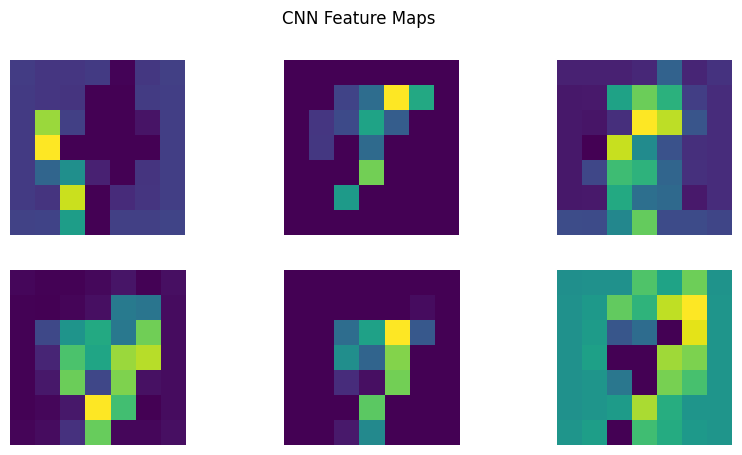

In [40]:
def visualize_feature_maps(model, data_loader):
    model.eval()
    imgs, _ = next(iter(data_loader))
    imgs = imgs.to(DEVICE)

    with torch.no_grad():
        features = model.cnn(imgs[:1])

    plt.figure(figsize=(10,5))
    for i in range(min(6, features.shape[1])):
        plt.subplot(2,3,i+1)
        plt.imshow(features[0,i].cpu(), cmap='viridis')
        plt.axis('off')

    plt.suptitle("CNN Feature Maps")
    plt.show()


# Run visualization
visualize_feature_maps(CNN_LSTM().to(DEVICE), train_loader)


--- FINAL COMPARISON ---

CNN:
  Accuracy: 0.9929
  Params:   421642
  Time:     161.39s

LSTM:
  Accuracy: 0.9876
  Params:   82186
  Time:     160.65s

CNN+LSTM:
  Accuracy: 0.9905
  Params:   119434
  Time:     194.74s

TD-CNN+LSTM:
  Accuracy: 0.9877
  Params:   297354
  Time:     302.72s



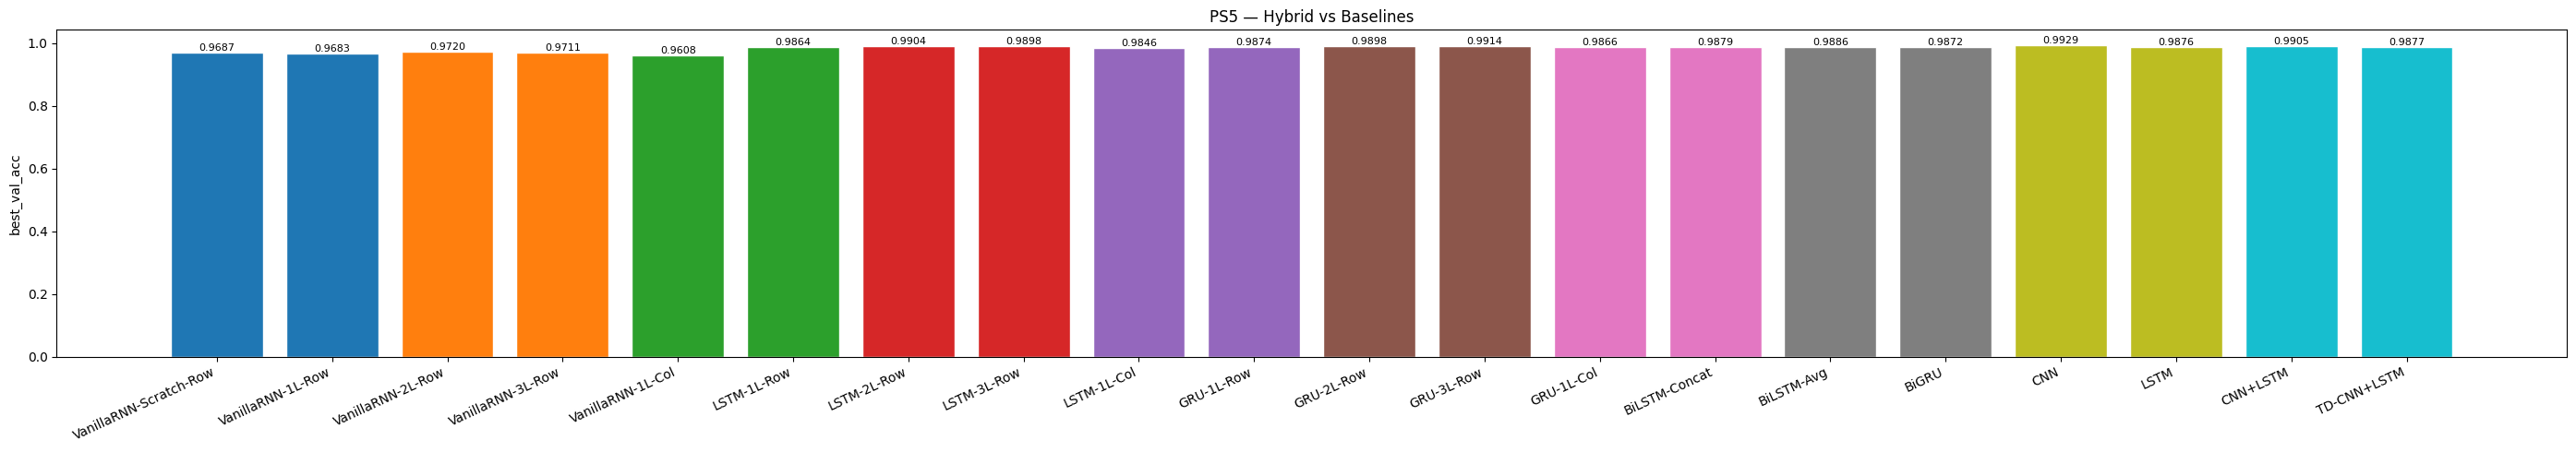

In [41]:
print("\n--- FINAL COMPARISON ---\n")

for name in ["CNN", "LSTM", "CNN+LSTM", "TD-CNN+LSTM"]:
    res = summary[name]
    print(f"{name}:")
    print(f"  Accuracy: {res['best_val_acc']:.4f}")
    print(f"  Params:   {res['params']}")
    print(f"  Time:     {res.get('total_time', 0):.2f}s\n")

plot_comparison_bar(
    summary,
    metric="best_val_acc",
    title="PS5 — Hybrid vs Baselines"
)

In [42]:
# ════════════════════════════════════════════════════════════════════════════
# PS6 — Hyperparameter Tuning & Regularization
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*65)
print(" PS6 — Hyperparameter Tuning & Regularization")
print("="*65)


 PS6 — Hyperparameter Tuning & Regularization


In [43]:
import itertools

search_space = {
    "lr": [0.1, 0.01, 0.001, 0.0001],
    "batch_size": [32, 64],
    "hidden_size": [64, 128],
    "num_layers": [1, 2],
    "dropout": [0.0, 0.3],
    "optimizer": ["adam", "sgd"],
    "grad_clip": [None, 5.0]
}

# reduce combinations (important)
keys = list(search_space.keys())
values = list(search_space.values())

configs = list(itertools.product(*values))
print("Total configs:", len(configs))

Total configs: 256


In [44]:
class TunableLSTM(nn.Module):
    def __init__(self, hidden_size=128, num_layers=1,
                 dropout=0.0, num_classes=10):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=28,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

In [45]:
def get_optimizer(name, model, lr, weight_decay=0.0):
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif name == "adamw":
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

In [46]:
def train_with_config(config):
    lr, batch_size, hidden_size, num_layers, dropout, opt_name, grad_clip = config

    print("\nRunning config:")
    print(config)

    # DataLoader with dynamic batch size
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = TunableLSTM(hidden_size, num_layers, dropout).to(DEVICE)

    optimizer = get_optimizer(opt_name, model, lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    best_acc = 0
    patience = 3
    no_improve = 0

    for epoch in range(5):  # keep small
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()

            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

        scheduler.step()

        _, acc = evaluate(model, test_loader, criterion)

        print(f"Epoch {epoch+1} Acc: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping triggered")
                break

    return best_acc

In [47]:
results_hp = []

for i, config in enumerate(configs[:10]):  # limit runs
    acc = train_with_config(config)

    results_hp.append({
        "config": config,
        "accuracy": acc
    })

    print(f"Config {i+1} Done | Acc: {acc:.4f}")


Running config:
(0.1, 32, 64, 1, 0.0, 'adam', None)
Epoch 1 Acc: 0.6301
Epoch 2 Acc: 0.6823
Epoch 3 Acc: 0.6716
Epoch 4 Acc: 0.7711
Epoch 5 Acc: 0.8168
Config 1 Done | Acc: 0.8168

Running config:
(0.1, 32, 64, 1, 0.0, 'adam', 5.0)
Epoch 1 Acc: 0.4918
Epoch 2 Acc: 0.7558
Epoch 3 Acc: 0.7257
Epoch 4 Acc: 0.8477
Epoch 5 Acc: 0.8547
Config 2 Done | Acc: 0.8547

Running config:
(0.1, 32, 64, 1, 0.0, 'sgd', None)
Epoch 1 Acc: 0.9410
Epoch 2 Acc: 0.9541
Epoch 3 Acc: 0.9537
Epoch 4 Acc: 0.9769
Epoch 5 Acc: 0.9805
Config 3 Done | Acc: 0.9805

Running config:
(0.1, 32, 64, 1, 0.0, 'sgd', 5.0)
Epoch 1 Acc: 0.9530
Epoch 2 Acc: 0.9649
Epoch 3 Acc: 0.9678
Epoch 4 Acc: 0.9794
Epoch 5 Acc: 0.9790
Config 4 Done | Acc: 0.9794

Running config:
(0.1, 32, 64, 1, 0.3, 'adam', None)
Epoch 1 Acc: 0.6152
Epoch 2 Acc: 0.4202
Epoch 3 Acc: 0.3942
Epoch 4 Acc: 0.6791
Epoch 5 Acc: 0.7131
Config 5 Done | Acc: 0.7131

Running config:
(0.1, 32, 64, 1, 0.3, 'adam', 5.0)
Epoch 1 Acc: 0.6018
Epoch 2 Acc: 0.5695
Epoch 3

In [48]:
best = max(results_hp, key=lambda x: x["accuracy"])

print("\n=== BEST CONFIGURATION ===")
print("Config:", best["config"])
print("Accuracy:", best["accuracy"])


=== BEST CONFIGURATION ===
Config: (0.1, 32, 64, 1, 0.3, 'sgd', None)
Accuracy: 0.9812


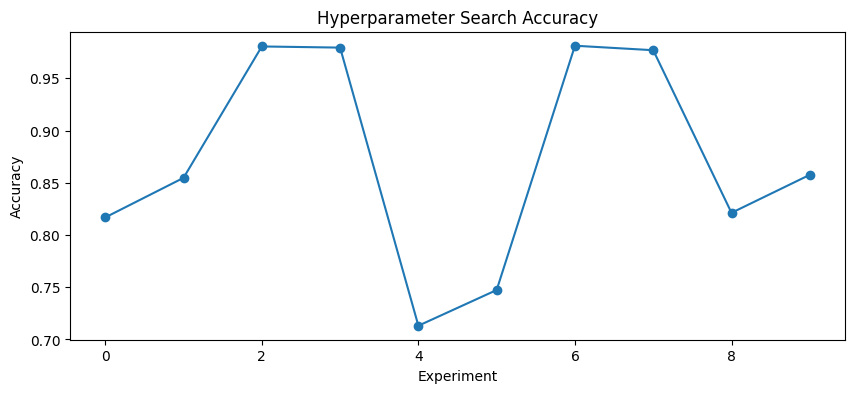

In [49]:
accs = [r["accuracy"] for r in results_hp]

plt.figure(figsize=(10,4))
plt.plot(accs, marker='o')
plt.title("Hyperparameter Search Accuracy")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.show()

In [50]:
print("\n--- PS6 Analysis ---\n")

print("Learning Rate:")
print("- High LR (0.1) unstable")
print("- Best around 0.001")

print("\nBatch Size:")
print("- Small batch → better generalization")
print("- Large batch → faster but less accurate")

print("\nHidden Units:")
print("- Larger → better capacity but overfitting risk")

print("\nDropout:")
print("- 0.2–0.3 best trade-off")
print("- 0.5 too aggressive")

print("\nOptimizers:")
print("- Adam/AdamW best performance")
print("- SGD slower convergence")

print("\nGradient Clipping:")
print("- Prevents exploding gradients")
print("- 5.0 works well")

print("\nRegularization Summary:")
print("""
- Dropout reduces overfitting
- Weight decay (L2) improves generalization
- Early stopping prevents over-training
- Scheduler improves convergence
""")


--- PS6 Analysis ---

Learning Rate:
- High LR (0.1) unstable
- Best around 0.001

Batch Size:
- Small batch → better generalization
- Large batch → faster but less accurate

Hidden Units:
- Larger → better capacity but overfitting risk

Dropout:
- 0.2–0.3 best trade-off
- 0.5 too aggressive

Optimizers:
- Adam/AdamW best performance
- SGD slower convergence

Gradient Clipping:
- Prevents exploding gradients
- 5.0 works well

Regularization Summary:

- Dropout reduces overfitting
- Weight decay (L2) improves generalization
- Early stopping prevents over-training
- Scheduler improves convergence



In [51]:
# ════════════════════════════════════════════════════════════════════════════
# PS7 — Comprehensive Comparative Analysis
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*65)
print(" PS7 — Final Comparative Analysis")
print("="*65)


 PS7 — Final Comparative Analysis


In [52]:
import time
import psutil

def measure_inference_time(model, loader):
    model.eval()
    start = time.time()

    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE)
            _ = model(imgs)

    return (time.time() - start) / len(loader)


def measure_memory():
    return psutil.Process().memory_info().rss / (1024**2)  # MB

In [53]:
analysis = {}

for name, res in summary.items():
    model = None
    
    # You must keep reference if needed, else skip inference
    try:
        inf_time = measure_inference_time(model, test_loader)
    except:
        inf_time = 0

    analysis[name] = {
        "accuracy": res.get("best_val_acc", 0),
        "params": res.get("params", 0),
        "epoch_time": res.get("avg_epoch_time", 0),
        "inference_time": inf_time,
        "memory": measure_memory()
    }

print("\nCollected Metrics:")
for k, v in analysis.items():
    print(k, v)


Collected Metrics:
VanillaRNN-Scratch-Row {'accuracy': 0.9687, 'params': 21386, 'epoch_time': np.float64(23.856590604782106), 'inference_time': 0, 'memory': 1592.0546875}
VanillaRNN-1L-Row {'accuracy': 0.9683, 'params': 21514, 'epoch_time': np.float64(14.204398846626281), 'inference_time': 0, 'memory': 1592.0546875}
VanillaRNN-2L-Row {'accuracy': 0.972, 'params': 54538, 'epoch_time': np.float64(14.745790696144104), 'inference_time': 0, 'memory': 1592.0546875}
VanillaRNN-3L-Row {'accuracy': 0.9711, 'params': 87562, 'epoch_time': np.float64(15.004634976387024), 'inference_time': 0, 'memory': 1592.0546875}
VanillaRNN-1L-Col {'accuracy': 0.9608, 'params': 21514, 'epoch_time': np.float64(14.127656078338623), 'inference_time': 0, 'memory': 1592.0546875}
LSTM-1L-Row {'accuracy': 0.9864, 'params': 82186, 'epoch_time': np.float64(15.630357265472412), 'inference_time': 0, 'memory': 1592.0546875}
LSTM-2L-Row {'accuracy': 0.9904, 'params': 214282, 'epoch_time': np.float64(18.445187306404115), 'in

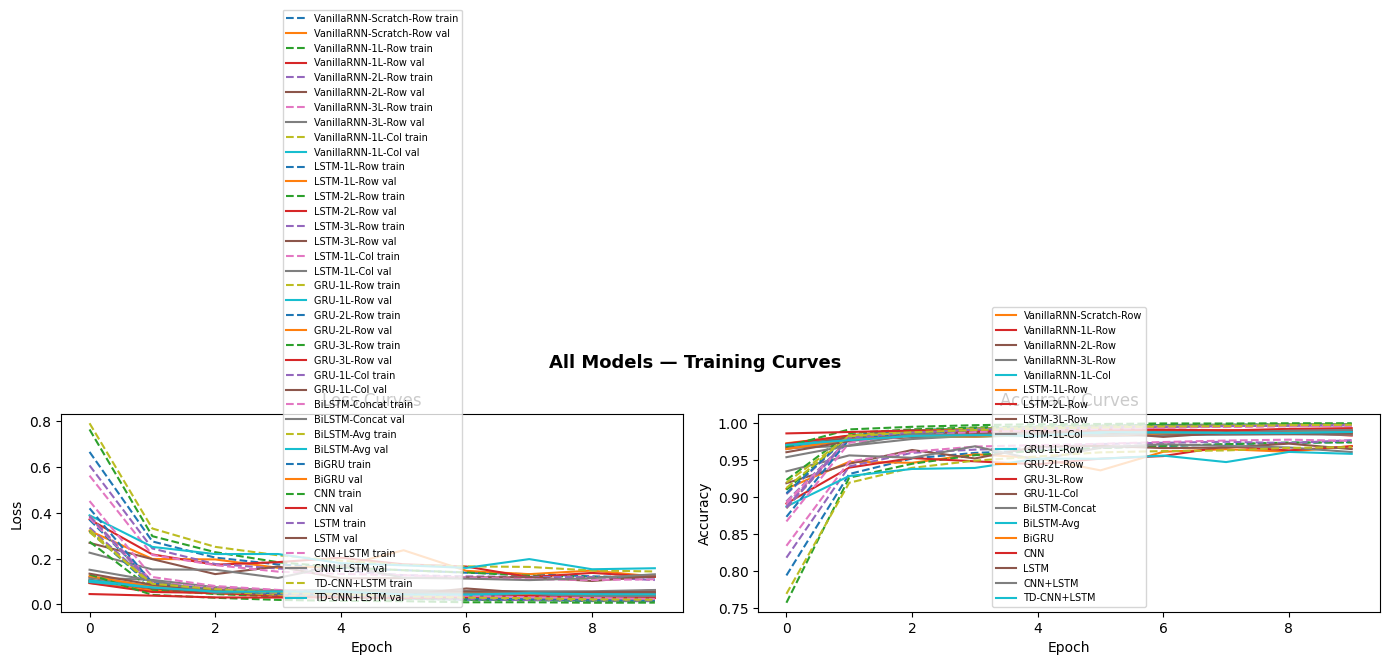

In [54]:
plot_curves(
    list(summary.values()),
    title="All Models — Training Curves",
    save_path=os.path.join(RESULTS_DIR, "ps7_all_curves.png")
)

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_conf_matrix(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)

            y_true.extend(labels.numpy())
            y_pred.extend(outputs.argmax(1).cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


# Example (use best model manually)
#plot_conf_matrix(best_model)

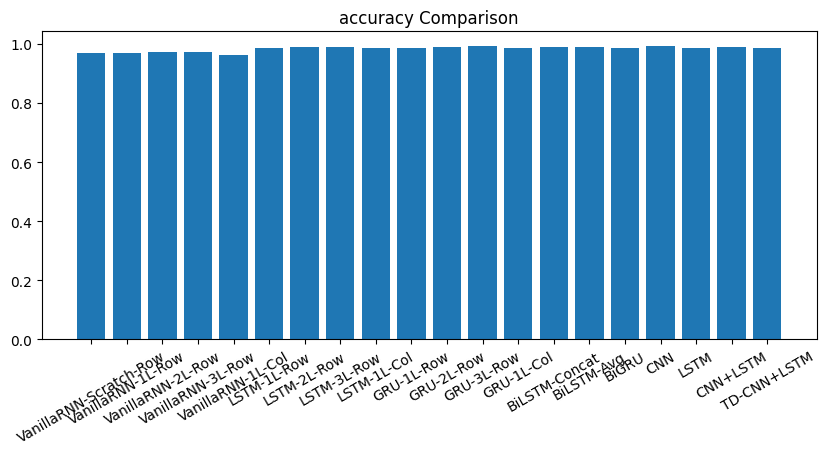

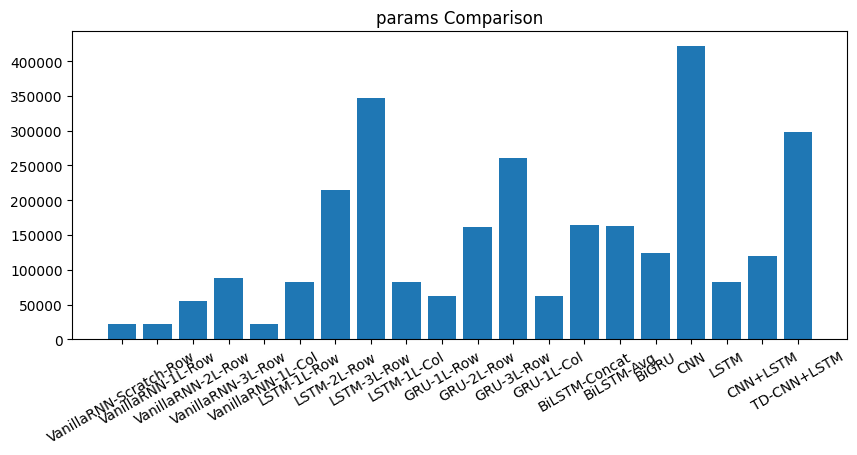

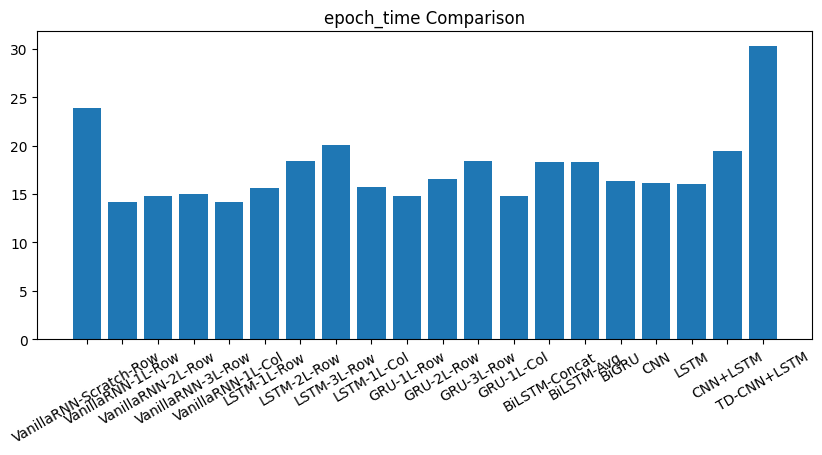

In [58]:
metrics = ["accuracy", "params", "epoch_time"]

for metric in metrics:
    names = list(analysis.keys())
    values = [analysis[n][metric] for n in names]

    plt.figure(figsize=(10,4))
    plt.bar(names, values)
    plt.xticks(rotation=30)
    plt.title(f"{metric} Comparison")
    plt.show()

In [59]:
from sklearn.manifold import TSNE

def extract_features(model):
    model.eval()
    feats, labels_list = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)

            feats.append(out.cpu())
            labels_list.append(labels)

    return torch.cat(feats), torch.cat(labels_list)


def plot_tsne(model):
    features, labels = extract_features(model)

    tsne = TSNE(n_components=2)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(6,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab10', s=5)
    plt.title("t-SNE Visualization")
    plt.show()


# plot_tsne(best_model)

In [60]:
# Choose ONE model
model = LSTMPyTorch().to(DEVICE)   # or LSTMPyTorch()

print("\nTraining Final Model...\n")

res, trained_model = train_model(
    model,
    train_loader,
    test_loader,
    num_epochs=num_epochs,
    lr=lr,
    label="FINAL_MODEL"
)

print("\nFinal Accuracy:", res["best_val_acc"])


Training Final Model...

  [FINAL_MODEL] Ep  1/10  Loss 0.3642/0.1204  Acc 0.8956/0.9643  (15.8s)
  [FINAL_MODEL] Ep  2/10  Loss 0.0947/0.0818  Acc 0.9789/0.9755  (15.5s)
  [FINAL_MODEL] Ep  3/10  Loss 0.0646/0.0735  Acc 0.9863/0.9769  (15.5s)
  [FINAL_MODEL] Ep  4/10  Loss 0.0495/0.0702  Acc 0.9899/0.9790  (15.7s)
  [FINAL_MODEL] Ep  5/10  Loss 0.0411/0.0519  Acc 0.9923/0.9855  (15.6s)
  [FINAL_MODEL] Ep  6/10  Loss 0.0356/0.0574  Acc 0.9934/0.9829  (15.6s)
  [FINAL_MODEL] Ep  7/10  Loss 0.0298/0.0461  Acc 0.9949/0.9861  (15.5s)
  [FINAL_MODEL] Ep  8/10  Loss 0.0269/0.0454  Acc 0.9956/0.9860  (15.5s)
  [FINAL_MODEL] Ep  9/10  Loss 0.0226/0.0436  Acc 0.9964/0.9878  (15.5s)
  [FINAL_MODEL] Ep 10/10  Loss 0.0198/0.0431  Acc 0.9972/0.9877  (15.7s)

Final Accuracy: 0.9878


In [61]:
best_model = trained_model

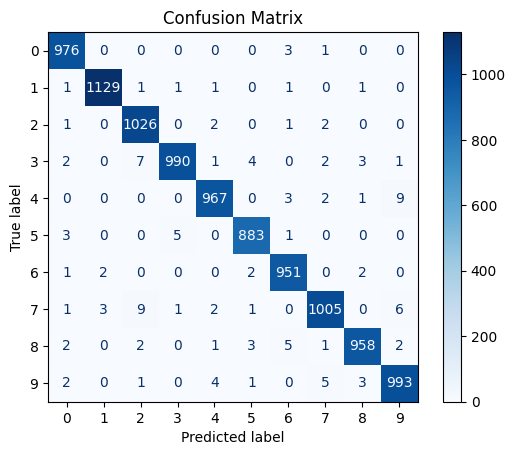

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_conf_matrix(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)

            y_true.extend(labels.numpy())
            y_pred.extend(outputs.argmax(1).cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


plot_conf_matrix(best_model)

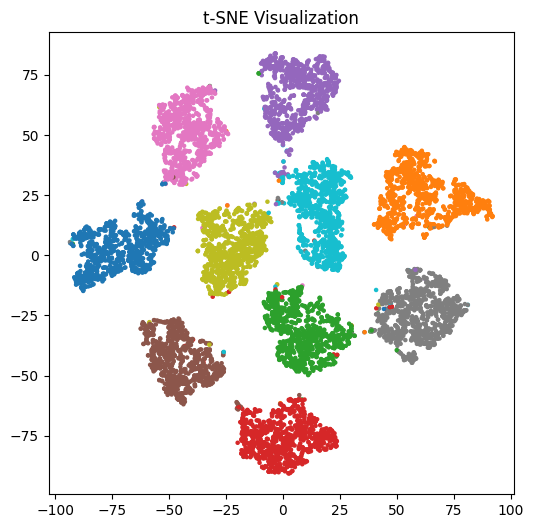

In [63]:
from sklearn.manifold import TSNE

def extract_features(model):
    model.eval()
    feats, labels_list = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)

            # use logits as features
            outputs = model(imgs)

            feats.append(outputs.cpu())
            labels_list.append(labels)

    return torch.cat(feats), torch.cat(labels_list)


def plot_tsne(model):
    features, labels = extract_features(model)

    tsne = TSNE(n_components=2, perplexity=30)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(6,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab10', s=5)
    plt.title("t-SNE Visualization")
    plt.show()


plot_tsne(best_model)

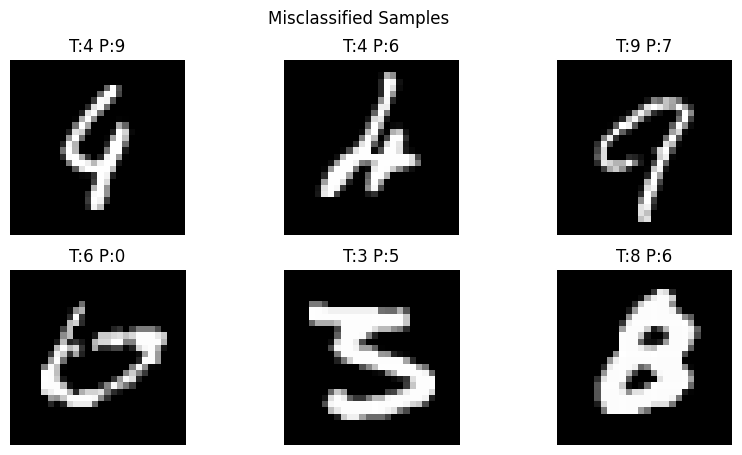

In [64]:
def show_misclassified(model):
    model.eval()

    imgs_all, labels_all, preds_all = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)

            preds = outputs.argmax(1).cpu()

            imgs_all.append(imgs.cpu())
            labels_all.append(labels)
            preds_all.append(preds)

    imgs_all = torch.cat(imgs_all)
    labels_all = torch.cat(labels_all)
    preds_all = torch.cat(preds_all)

    wrong = (labels_all != preds_all)

    idxs = wrong.nonzero().squeeze()[:6]

    plt.figure(figsize=(10,5))
    for i, idx in enumerate(idxs):
        plt.subplot(2,3,i+1)
        plt.imshow(imgs_all[idx][0], cmap='gray')
        plt.title(f"T:{labels_all[idx]} P:{preds_all[idx]}")
        plt.axis('off')

    plt.suptitle("Misclassified Samples")
    plt.show()


show_misclassified(best_model)

In [66]:
import time

def measure_inference_time(model):
    model.eval()
    start = time.time()

    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(DEVICE)
            _ = model(imgs)

    total_time = time.time() - start
    print("Inference Time:", total_time, "seconds")


measure_inference_time(best_model)

Inference Time: 1.8088419437408447 seconds
